# Project Sidekick

##### ==========================================
##### Step 1: Imports
##### ==========================================

In [1]:
# LangGraph core components
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [2]:
# Data handling and typing
from typing import TypedDict, Annotated, Sequence, Optional
from operator import add

In [3]:
# Ollama connection
from langchain_ollama import ChatOllama

In [4]:
# Message types
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool

In [5]:
# Web browsing tool
from playwright.async_api import async_playwright

In [6]:
# Utilities for visualization and UI
from IPython.display import Image, display
import gradio as gr
import uuid
import nest_asyncio
import json
import asyncio

In [7]:
# Allows the browser to run inside the Gradio environment
nest_asyncio.apply()

##### ==========================================
##### Step 2: Define State
##### ==========================================

In [8]:
class AgentState(TypedDict):
    # List of messages in the chat
    messages: Annotated[Sequence, add]
    # The goal the AI is trying to reach
    goal: str
    # Feedback if the AI made a mistake
    feedback: Optional[str]
    # True if the goal is achieved
    goal_met: bool
    # True if AI needs to ask the user for more info
    help_needed: bool

##### ==========================================
##### Step 3: Initialize LLM
##### ==========================================

In [9]:
ai_model = ChatOllama(
    model = "gpt-oss:120b-cloud",
    temperature= 0,
    num_predict= 1000,
    base_url = "http://localhost:11434"
)

##### ==========================================
##### Step 4: Define Tools
##### ==========================================

In [10]:
#from gradio import context


browser_instance = None
context_instance = None

@tool
async def search_the_web(url:str) -> str:
    """
    Opens a website and reads the text on the page.
    """
    global browser_instance, context_instance
    
    try:
        if browser_instance is None:
            # playwright = It is like a bot.
            playwright_manager = await async_playwright().start()
            # playwright_manager = Consider it a Robot. 
            # chromium = It is an Automation extension of Google Chrome.
            # launch() = Switch for Opening or Closing Browser on Display. 
            # headless = True= Perform in Background,      False = Perfom in Front of Display.
            browser_instance = await playwright_manager.chromium.launch(headless= False)
            
            # Below code is creating a fake id for Bot so that it can appear Human.
            # And by pass bot test.
            # browser_instance = Browser App of Chromium.
            # .new_context() = Opens New, Clean, Private Session, like Incognito Window.
            # user_agent = Describes the "user" 
            # "Mozilla/5.0..." = Human like ID Card Number.
            context_instance = await browser_instance.new_context(
                user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
            )

        # Opening new Incognito Web Page and saving it in page.
        page = await context_instance.new_page()
        print(f"[Tool] Opening Website: {url}...")
 
        # Going to specific website.
        await page.goto(url, timeout= 30000 , wait_until= "domcontentloaded" )
        page_text = await page.inner_text("body")

        # Closing the page
        await page.close()
        return f"Website Content from {url}:\n\n{page_text[:5000]}"

    except Exception as error:
        return f"Error reading {url}: {str(error)}"



web_tools_list = [search_the_web]
ai_with_tools = ai_model.bind_tools(web_tools_list)        

##### ==========================================
##### Step 5: Define Agent Nodes
##### ==========================================

In [11]:
#from langchain_core import messages


def researcher_node(state: AgentState) -> dict:
    """Researcher node: finds information and uses tools."""
    print("\n[RESEARCHER] Thinking... 🧠")


    instruction = f"You are a professional researcher. YOUR GOAL: {state['goal']}"
    if state.get("feedback"):
        instruction += f"\n\nFIX THESE MISTAKES: {state['feedback']}"

    # "list" = converts tuple message into list style.
    # "SystemMessage" = It is langgraph/ langchain style of System Message. It takes list.
    # "list(state["messages"])" = It takes past message history.
    full_conversation = [SystemMessage(content = instruction)] + list(state["messages"])

    response = ai_with_tools.invoke(full_conversation)

    if response.tool_calls:
        # response.tool_calls: The big list of tool requests the AI made.
        # for t in ...: "Look at every tool request one by one."
        # t['name']: "Just grab the name of the tool and ignore the rest of the complex data."
        print(f"[RESEARCHER] 🛠️ Using Tools: {[t['name'] for t in response.tool_calls]}")
    
    else:
        print("[RESEARCHER] ✍️ Writing final answer...")

    return {"messages": [response]}

In [12]:
def checker_node(state: AgentState) -> dict:
    """Checker node: verifies if the answer meets the goal."""
    print("\n[CHECKER] Verifying answer... ✅")

    # Taking last message
    # Use state["messages"][-1] when you have a history. 
    # And you want to find the most recent thing said.
    last_answer = state["messages"][-1].content # Reading the Group Chat at very last one.
    check_prompt = f"""Check this work. GOAL: {state['goal']}\nANSWER: {last_answer}\n
    Return ONLY JSON: {{
    "feedback": "string", 
    "goal_met": true/false, 
    "help_needed": true/false
    }}"""
    
    # Use check_response when you just called the AI 
    # and it gave you a single, fresh answer.
    check_response = ai_model.invoke(check_prompt) 

    try:
        text = check_response.content

        # 'text.rfind('}') = 'r' means 'Reverse'.
        # + 1: In Python, when we cut text, the end point is not included. 
        # Adding 1 ensures the final } is actually included in the cut.
        # find() = It means find() is like a GPS. It gives you the exact coordinate (index number) of the { and }, 
        # allowing you to cut perfectly around the data, no matter where it is hidden in the text.

        # text.find('{') and text.rfind('}') = It gives INDEX of it. NUMBER
        start, end = text.find('{'), text.rfind('}') + 1 


        # text[start:end]= This is the Slicing.
        # It uses the numbers we found earlier to cut out only the part between the { and the }.
        # Unpacks the "text box" into a real Python dictionary we can actually use
        # Convert JSON string to Python dictionary.
        data = json.loads(text[start:end])
        print(f"[CHECKER] Result: Goal Met = {data['goal_met']}")

    except Exception:
        data = {"feedback": "Evaluation failed", "goal_met": False, "help_needed": True}


    # AIMessage(...): A special wrapper. It tells Python: "This message came from an AI, not a human."
    return {
        "messages": [AIMessage(content=f"Checker's Feedback: {data['feedback']}")],
        "feedback": data["feedback"],
        "goal_met": data["goal_met"],
        "help_needed": data["help_needed"]
    }

##### ==========================================
##### Step 6: Define Decision Routers
##### ==========================================

In [13]:
def decide_after_research(state: AgentState) -> str:
    """Decides whether to use a tool or check the answer."""
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "checker"

In [14]:
def decide_after_check(state: AgentState) -> str:
    """Decides if the agent is finished or needs to retry."""
    
    # state["goal_met"]: "Is the success criteria finished?" (True/False).
    # state["help_needed"]: "Is the AI stuck and needing a human's help?" (True/False).
    if state["goal_met"] or state["help_needed"] :
        return END

    # Otherwise do more research.
    return "researcher"   

##### ==========================================
##### Step 7: Build the Graph
##### ==========================================

In [15]:
#from langgraph import graph


graph_builder = StateGraph(AgentState)

graph_builder.add_node("researcher", researcher_node)
graph_builder.add_node("tools", ToolNode(tools= web_tools_list))
graph_builder.add_node("checker", checker_node)

graph_builder.set_entry_point("researcher")


#{"tools": "tools", "checker": "checker"}: The Destination Map. 
# It maps the brain's decision to a real place.
#           If the brain says "tools", go to the "tools" node.
#           If the brain says "checker", go to the "checker" node.

# 'in a Conditional Edge', the AI has to make a choice. 
# Without this map, the AI wouldn't know which function to run next based on its decision.
graph_builder.add_conditional_edges("researcher", decide_after_research, {"tools": "tools", "checker": "checker"})
graph_builder.add_edge("tools", "researcher")
graph_builder.add_conditional_edges("checker", decide_after_check, {"researcher": "researcher", END: END} )

##### ==========================================
##### Step 8: Compile and Visualize
##### ==========================================

In [16]:
memory_storage = MemorySaver()
compiled_agent = graph_builder.compile(checkpointer= memory_storage)


--- Generating Agent Architecture ---


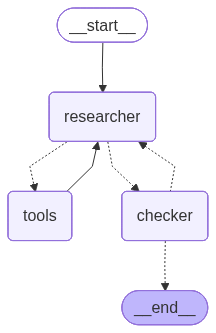

In [17]:
print("\n--- Generating Agent Architecture ---")

try:
    # Directly display the graph bytes without saving to a file
    display(Image(compiled_agent.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: Print the ASCII version if image generation fails
    print(compiled_agent.get_graph().print_ascii())

##### ==========================================
##### Step 9: Run the Agent (Gradio UI)
##### ==========================================

In [18]:
async def handle_user_request(user_text, goal_text, chat_history, thread_id):
    """Handles user input and runs the agent."""
    print(f"\n🚀 STARTING TASK: {user_text}")

    # 1. Create a "Unique Locker ID" so the AI doesn't mix up different users
    config = {"configurable": {"thread_id": thread_id}}

    # 2. Create the "Save Game" file (State) to track the goal and progress
    starting_data = {
        "messages": [HumanMessage(content=user_text)],            # The current chat
        "goal": goal_text, # What 'winning' looks like
        "feedback": None,      # Start with no complaints from the boss
        "goal_met": False, # Goal is not met yet
        "help_needed": False      # AI isn't stuck yet
    }

    # 3. Send the state and locker ID to the AI brain and wait for the result
    final_result = await compiled_agent.ainvoke(starting_data, config=config)

    # 4. Prepare the new pieces of the conversation to show the user
    user_msg = {"role": "user", "content": user_text} # What the user said
    
    # Grabbing the 2nd to last message (The AI's final answer)
    ai_answer = {"role": "assistant", "content": final_result["messages"][-2].content} 
    
    # Grabbing the very last message (The Boss/Evaluator's feedback)
    checker_msg = {"role": "assistant", "content": final_result["messages"][-1].content}

    # 5. Glue the new messages onto the old history list and send it back to the screen
    return chat_history + [user_msg, ai_answer, checker_msg]

In [19]:
async def reset_chat():
    """Resets the UI."""

    # str(uuid.uuid4()): This is the magic part. It generates a totally random, unique ID (like 550e8400-e29b...).
    #  uuid4(): Creates the random ID.
    #  str(): Turns that ID into text so the computer can read it.
    
    return "", "", None, str(uuid.uuid4())

#----------------- Gradio ----------------#

In [20]:
with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## 🤖 Simple AI Sidekick (Architecture Edition)")
    session_id = gr.State(str(uuid.uuid4()))
    with gr.Row():
        chatbot_display = gr.Chatbot(label="AI Sidekick", height=400, type="messages")
    with gr.Group():
        user_input_box = gr.Textbox(show_label=False, placeholder="What do you want me to do?")
        goal_input_box = gr.Textbox(show_label=False, placeholder="What is the success criteria?")
    with gr.Row():
        btn_reset = gr.Button("Reset", variant="stop")
        btn_go = gr.Button("Go!", variant="primary")
    btn_go.click(handle_user_request, [user_input_box, goal_input_box, chatbot_display, session_id], [chatbot_display])
    btn_reset.click(reset_chat, [], [user_input_box, goal_input_box, chatbot_display, session_id])

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.



🚀 STARTING TASK: "What is the current price of Bitcoin?"

[RESEARCHER] Thinking... 🧠
[RESEARCHER] 🛠️ Using Tools: ['search_the_web']
[Tool] Opening Website: https://coinmarketcap.com/currencies/bitcoin/...

[RESEARCHER] Thinking... 🧠
[RESEARCHER] ✍️ Writing final answer...

[CHECKER] Verifying answer... ✅
[CHECKER] Result: Goal Met = False

🚀 STARTING TASK: "Who is the current CEO of NVIDIA?"

[RESEARCHER] Thinking... 🧠
[RESEARCHER] 🛠️ Using Tools: ['search_the_web']
[Tool] Opening Website: https://www.nvidia.com/en-us/about-nvidia/leadership/...

[RESEARCHER] Thinking... 🧠
[RESEARCHER] 🛠️ Using Tools: ['search_the_web']
[Tool] Opening Website: https://en.wikipedia.org/wiki/Nvidia...

[RESEARCHER] Thinking... 🧠
[RESEARCHER] ✍️ Writing final answer...

[CHECKER] Verifying answer... ✅
[CHECKER] Result: Goal Met = True

🚀 STARTING TASK: "Summarize the latest news about SpaceX."

[RESEARCHER] Thinking... 🧠
[RESEARCHER] 🛠️ Using Tools: ['search_the_web']
[Tool] Opening Website: https://www

Exception in callback _ProactorBasePipeTransport._call_connection_lost(None)
handle: <Handle _ProactorBasePipeTransport._call_connection_lost(None)>
Traceback (most recent call last):
  File "C:\Users\lenov\AppData\Local\Programs\Python\Python311\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "C:\Users\lenov\AppData\Local\Programs\Python\Python311\Lib\asyncio\proactor_events.py", line 165, in _call_connection_lost
    self._sock.shutdown(socket.SHUT_RDWR)
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
